Ridership ≈ Service × Demand × Accessibility

In [1]:
import sys
!{sys.executable} -m ensurepip --upgrade

Looking in links: /tmp/tmprbp_lw3_


In [2]:
import sys
!{sys.executable} -m pip install linearmodels


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip


In [3]:
# Importing necessary package 
import pandas as pd 
import geopandas as gpd
pd.set_option('display.max_columns', None)
import os
import google.auth
import gcsfs
fs = gcsfs.GCSFileSystem()
import statsmodels.api as sm
import numpy as np
from scipy.stats import skew


import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [4]:
GCS_FILE_PATH = 'gs://calitp-analytics-data/data-analyses/ahsc_grant/ahsc_riderships/AHSC_2026'

In [5]:
with fs.open(f"{GCS_FILE_PATH}/stop_route_df_block.parquet", "rb") as f: 
    stop_route_df = gpd.read_parquet(f)

with fs.open(f"{GCS_FILE_PATH}/stop_route_df_saturday_block.parquet", "rb") as f: 
    stop_route_df_saturday = gpd.read_parquet(f)

with fs.open(f"{GCS_FILE_PATH}/stop_route_df_sunday_block.parquet", "rb") as f: 
    stop_route_df_sunday = gpd.read_parquet(f)

In [6]:
stop_route_df.head(2)

,organization_name,feed_key,stop_id,stop_name,stop_code,n_arrivals,n_routes,pt_geom,day_type,route_id_list,average_daily_boardings,average_daily_alightings,start_date,end_date,geometry,total_pop_adj,median_household_income_adj,employed_pop_adj,households_no_vehicle_adj,total_youth_adj,inc_extremelylow_adj,inc_verylow_adj,inc_low_adj,inc_total_lowincome_adj,jobs_tot_work_adj,jobs_tot_home_adj,poi_total_adj,lowincome_total_adj
0,Gold Coast Transit,3cb676436aad669e52042c0e97a9a051,VNACLR1,.,None,14.0,1.0,POINT(-119.294028 34.343645),Weekday,['16'],0.00000,3.000000,2025-05-01,2025-05-31,POINT (64936.582 -407800.219),6.544018,3.982932e+02,3.111196,0.073311,1.272796,0.291879,0.444580,0.246698,0.983157,1.460299,4.831754,0.026697,0.736459
1,Samtrans,db97cc02836aa5f0cf647d80160b23ec,345017,1000 El Camino Real-Menlo College,345017,72.0,1.0,POINT(-122.191284 37.457543),Weekday,['ECR-216'],9.52381,24.571429,2025-08-01,2025-08-31,POINT (-193547.746 -59885.338),747.176914,-5.693852e+06,364.161050,26.044966,54.387092,26.033693,17.920044,0.233345,44.187082,522.731089,439.308142,8.601501,43.953737


In [7]:
# Convert n_arrivals and n_routes to integer
stop_route_df['n_arrivals'] = stop_route_df['n_arrivals'].fillna(0).astype(int)
stop_route_df['n_routes'] = stop_route_df['n_routes'].fillna(0).astype(int)
stop_route_df_saturday['n_arrivals'] = stop_route_df_saturday['n_arrivals'].fillna(0).astype(int)
stop_route_df_saturday['n_routes'] = stop_route_df_saturday['n_routes'].fillna(0).astype(int)
stop_route_df_sunday['n_arrivals'] = stop_route_df_sunday['n_arrivals'].fillna(0).astype(int)
stop_route_df_sunday['n_routes'] = stop_route_df_sunday['n_routes'].fillna(0).astype(int)

In [8]:
stop_route_df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 21315 entries, 0 to 21314
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   organization_name            21315 non-null  object  
 1   feed_key                     21315 non-null  object  
 2   stop_id                      21315 non-null  object  
 3   stop_name                    21315 non-null  object  
 4   stop_code                    20594 non-null  object  
 5   n_arrivals                   21315 non-null  int64   
 6   n_routes                     21315 non-null  int64   
 7   pt_geom                      21315 non-null  object  
 8   day_type                     21315 non-null  object  
 9   route_id_list                21315 non-null  object  
 10  average_daily_boardings      21315 non-null  float64 
 11  average_daily_alightings     19138 non-null  float64 
 12  start_date                   21315 non-null  object 

In [9]:
# Min-max normalize selected columns to a 0–1 scale
# Each value is rescaled relative to the column minimum and maximum:
# (x - min) / (max - min)
# Resulting "_norm" columns allow comparison across variables with different units/scales
cols = ["total_pop_adj", "jobs_tot_work_adj", "jobs_tot_home_adj", "poi_total_adj"]

for c in cols:
    stop_route_df[c + "_norm"] = (
        (stop_route_df[c] - stop_route_df[c].min()) /
        (stop_route_df[c].max() - stop_route_df[c].min())
    )

In [10]:
stop_route_df.columns

Index(['organization_name', 'feed_key', 'stop_id', 'stop_name', 'stop_code',
       'n_arrivals', 'n_routes', 'pt_geom', 'day_type', 'route_id_list',
       'average_daily_boardings', 'average_daily_alightings', 'start_date',
       'end_date', 'geometry', 'total_pop_adj', 'median_household_income_adj',
       'employed_pop_adj', 'households_no_vehicle_adj', 'total_youth_adj',
       'inc_extremelylow_adj', 'inc_verylow_adj', 'inc_low_adj',
       'inc_total_lowincome_adj', 'jobs_tot_work_adj', 'jobs_tot_home_adj',
       'poi_total_adj', 'lowincome_total_adj', 'total_pop_adj_norm',
       'jobs_tot_work_adj_norm', 'jobs_tot_home_adj_norm',
       'poi_total_adj_norm'],
      dtype='object')

In [11]:
stop_route_df["land_use_index"] = (
    stop_route_df["total_pop_adj_norm"] +
    stop_route_df["jobs_tot_work_adj_norm"] +
    stop_route_df["jobs_tot_home_adj_norm"] +    
    stop_route_df["poi_total_adj_norm"]
) / 4

In [13]:
stop_route_df.head(5)

,organization_name,feed_key,stop_id,stop_name,stop_code,n_arrivals,n_routes,pt_geom,day_type,route_id_list,average_daily_boardings,average_daily_alightings,start_date,end_date,geometry,total_pop_adj,median_household_income_adj,employed_pop_adj,households_no_vehicle_adj,total_youth_adj,inc_extremelylow_adj,inc_verylow_adj,inc_low_adj,inc_total_lowincome_adj,jobs_tot_work_adj,jobs_tot_home_adj,poi_total_adj,lowincome_total_adj,total_pop_adj_norm,jobs_tot_work_adj_norm,jobs_tot_home_adj_norm,poi_total_adj_norm,total_pop_adj_winsor,jobs_tot_work_adj_winsor,jobs_tot_home_adj_winsor,poi_total_adj_winsor,land_use_index
0,Gold Coast Transit,3cb676436aad669e52042c0e97a9a051,VNACLR1,.,None,14,1,POINT(-119.294028 34.343645),Weekday,['16'],0.000000,3.000000,2025-05-01,2025-05-31,POINT (64936.582 -407800.219),6.544018,3.982932e+02,3.111196,0.073311,1.272796,0.291879,0.444580,0.246698,0.983157,1.460299,4.831754,0.026697,0.736459,0.005348,0.005043,0.005043,0.005043,38.405102,20.311590,23.365331,0.207602,0.005120
1,Samtrans,db97cc02836aa5f0cf647d80160b23ec,345017,1000 El Camino Real-Menlo College,345017,72,1,POINT(-122.191284 37.457543),Weekday,['ECR-216'],9.523810,24.571429,2025-08-01,2025-08-31,POINT (-193547.746 -59885.338),747.176914,-5.693852e+06,364.161050,26.044966,54.387092,26.033693,17.920044,0.233345,44.187082,522.731089,439.308142,8.601501,43.953737,0.185175,0.520291,0.270889,0.377011,747.176914,522.731089,439.308142,8.601501,0.338342
2,Samtrans,db97cc02836aa5f0cf647d80160b23ec,343119,1011 Crestview Dr,343119,5,1,POINT(-122.284103 37.484282),Weekday,['61-216'],1.444444,1.888889,2025-08-01,2025-08-31,POINT (-201672.936 -56720.285),601.416886,8.785326e+04,297.059274,4.489925,132.520560,5.399225,7.762556,8.970158,22.131939,45.168589,310.136187,0.728853,13.161781,0.135914,0.026085,0.158668,0.033591,601.416886,45.168589,310.136187,0.728853,0.088564
3,Samtrans,db97cc02836aa5f0cf647d80160b23ec,340606,1060 Carolan Ave,340606,7,1,POINT(-122.359627 37.586685),Weekday,['46-216'],10.333333,5.500000,2025-08-01,2025-08-31,POINT (-208056.618 -45176.880),1056.934144,1.048067e+05,664.165539,19.975234,229.744828,41.136933,45.437406,36.862322,123.436661,1468.013956,470.719223,11.938369,86.574339,0.312644,0.825475,0.302135,0.503917,1056.934144,1468.013956,470.719223,11.938369,0.486043
4,SDMTS,1fff52f9349da228c56eef492df5001b,12049,10th Av & A St,12049,18,3,POINT(-117.15569071 32.71857729),Weekday,"['110', '280', '290']",3.485637,42.889568,2024-09-01,2025-01-25,POINT (266991.751 -584189.054),6717.011217,2.420766e+05,4106.341003,1156.763383,70.647171,1017.735526,587.698534,687.336997,2292.771057,9098.968364,2715.560164,103.849640,1605.434060,0.995004,0.986441,0.995004,0.981562,5499.536054,9098.968364,2629.287162,103.849640,0.989503


### Log-linear Regression Model

In [14]:
stop_route_df_selected_org = stop_route_df[
    stop_route_df['organization_name'].isin([
        'SamTrans',
        'Golden Gate Transit',
        'Long Beach Transit',
        'SDMTS',
        # 'Golden Gate Park Shuttle',
        # 'Fresno County',
        'San Francisco Bay Area Rapid Transit District',
        'Big Blue Bus',
        'Caltrain',
        # 'Culver City Bus',
        # 'Foothill Transit',
        'Riverside Transit',
        'Gold Coast Transit',
        'SacRT Bus',
        'Orange County Transportation Authority'
    ])
]

In [15]:
# Log-linear regression
# Dependent variable: log('average_daily_boardings')
# Predictors: n_trips, n_routes, total_pop_adj, households_with_no_cars_adj, jobs_tot_adj

# Copy the dataframe
df = stop_route_df_selected_org.copy()

# 2. Create log dependent variable
# Replace 0 with NaN BEFORE log (log(0) = -inf)
df['log_boardings'] = np.log(df['average_daily_boardings'].replace(0, np.nan))
df['log_arrivals'] = np.log(df['n_arrivals'].replace(0, np.nan))

# 3. Select only rows with all needed variables
df = df.dropna(subset=[
    'average_daily_boardings',
    'log_arrivals',
    'land_use_index',
    'households_no_vehicle_adj',
    'total_youth_adj',
    'inc_total_lowincome_adj',
    # 'disabled_pop_adj'
    
])

# 4. Define Y and X
y = df['average_daily_boardings']

X = df[['log_arrivals',
        'land_use_index', 'households_no_vehicle_adj', 'total_youth_adj', 'inc_total_lowincome_adj']]

# 5. Add constant
X = sm.add_constant(X)

# 6. Fit model
model = sm.OLS(y, X).fit()

# 7. Show results
print(model.summary())

                               OLS Regression Results                              
Dep. Variable:     average_daily_boardings   R-squared:                       0.076
Model:                                 OLS   Adj. R-squared:                  0.076
Method:                      Least Squares   F-statistic:                     260.3
Date:                     Wed, 08 Jul 2026   Prob (F-statistic):          3.21e-268
Time:                             19:45:13   Log-Likelihood:            -1.2262e+05
No. Observations:                    15820   AIC:                         2.452e+05
Df Residuals:                        15814   BIC:                         2.453e+05
Df Model:                                5                                         
Covariance Type:                 nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------

- About 5.6% of the variation in dependent variable (here, stop-level ridership) is explained by the predictors in the model.
- 94.4% of the variation is due to other factors not captured by this model.
- Skew = 54.357 → Residuals are extremely asymmetric, violating normality.
- Kurtosis = 4235.968 → Residuals have ultra‑heavy tails, far from a normal distribution.
- JB statistic = 15 billion → The Jarque–Bera test overwhelmingly rejects normality.
- Durbin–Watson = 1.374 → Strong positive autocorrelation remains in the residuals.
- Condition number = 1.92e+04 → Predictors have scaling issues and possible multicollinearity.

### Checking Multicollinearity using VIF

VIF checks multicollinearity (correlation among predictors)

- Idea:
If a variable can be well explained by other predictors,
its coefficient becomes unstable and its standard error increases
- Interpretation:
VIF ≈ 1   → no correlation (good);
VIF > 5   → moderate concern;
VIF > 10  → serious multicollinearity
- Key point:
High VIF doesn't bias coefficients, but makes them noisy and hard to interpret

In [16]:
# Selecting only numeric regressors (Ridership ≈ Service × Demand × Accessibility)
X = stop_route_df_selected_org[
    [ 'inc_total_lowincome_adj',  'total_youth_adj', 'households_no_vehicle_adj']
].copy()

# Add constant
X = sm.add_constant(X)

vif_df = pd.DataFrame()
vif_df["variable"] = X.columns
vif_df["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif_df)

                    variable       VIF
0                      const  2.820265
1    inc_total_lowincome_adj  4.907976
2            total_youth_adj  1.644263
3  households_no_vehicle_adj  3.796504


All predictors have low VIFs (≈1–1.8), which means very little multicollinearity among chosen variables.
The model’s coefficients should therefore be stable and interpretable, with no inflation of standard errors.
The high VIF on the constant is not meaningful and can be ignored.

In [17]:
stop_route_df['average_daily_boardings'].describe()

count    21315.000000
mean        50.886533
std        504.743434
min          0.000000
25%          1.627594
50%          6.300000
75%         21.378255
max      41893.868537
Name: average_daily_boardings, dtype: float64

Data is highly skewed (28.63) .
Skewed data is data that isn’t evenly distributed around the center, values bunch up on one side and stretch into a long tail.
This means a few stops have very high boardings and push the distribution out into a long tail.
75% of stops board ≤ 20 people

Possible solution: Use a count model (Poisson or Negative Binomial)  
Other models to check:
- Poisson
- Negative Binomial (handles overdispersion better)
- Zero‑inflated Poisson (if many zeros)
- Zero‑inflated NB (most flexible)

### Add organization fixed effects

In [18]:
stop_route_df_selected_org.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 15820 entries, 0 to 21313
Data columns (total 37 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   organization_name            15820 non-null  object  
 1   feed_key                     15820 non-null  object  
 2   stop_id                      15820 non-null  object  
 3   stop_name                    15820 non-null  object  
 4   stop_code                    15144 non-null  object  
 5   n_arrivals                   15820 non-null  int64   
 6   n_routes                     15820 non-null  int64   
 7   pt_geom                      15820 non-null  object  
 8   day_type                     15820 non-null  object  
 9   route_id_list                15820 non-null  object  
 10  average_daily_boardings      15820 non-null  float64 
 11  average_daily_alightings     13661 non-null  float64 
 12  start_date                   15820 non-null  object  
 13

In [19]:
df = stop_route_df_selected_org.copy()

# Log transforms (safe)
df['log_boardings'] = np.log(df['average_daily_boardings'].replace(0, np.nan))
df['log_arrivals'] = np.log(df['n_arrivals'].replace(0, np.nan))

# Keep needed columns
df = df.dropna(subset=[
    'log_boardings',
    'log_arrivals',
    'land_use_index',
    'households_no_vehicle_adj',
    'total_youth_adj',
    'lowincome_total_adj',
    # 'disabled_pop_adj',
    'organization_name'
])

# Dependent variable
y = df['log_boardings']

# Predictors
X = df[
    ['log_arrivals',
     'land_use_index',
     'households_no_vehicle_adj',
     'total_youth_adj',
     'lowincome_total_adj',]
]

# Force numeric
y = pd.to_numeric(y)
X = X.apply(pd.to_numeric, errors='coerce')

# Organization fixed effects
org_fe = pd.get_dummies(df['organization_name'], drop_first=True).astype(float)

# Combine
X = pd.concat([X, org_fe], axis=1)

# Drop ANY remaining bad rows together (IMPORTANT STEP)
df_model = pd.concat([y, X], axis=1).dropna()

y = df_model['log_boardings']
X = df_model.drop(columns=['log_boardings'])

# Add constant
X = sm.add_constant(X)

# Fit model
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          log_boardings   R-squared:                       0.480
Model:                            OLS   Adj. R-squared:                  0.480
Method:                 Least Squares   F-statistic:                     1009.
Date:                Wed, 08 Jul 2026   Prob (F-statistic):               0.00
Time:                        19:45:13   Log-Likelihood:                -23318.
No. Observations:               14198   AIC:                         4.666e+04
Df Residuals:                   14184   BIC:                         4.677e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------

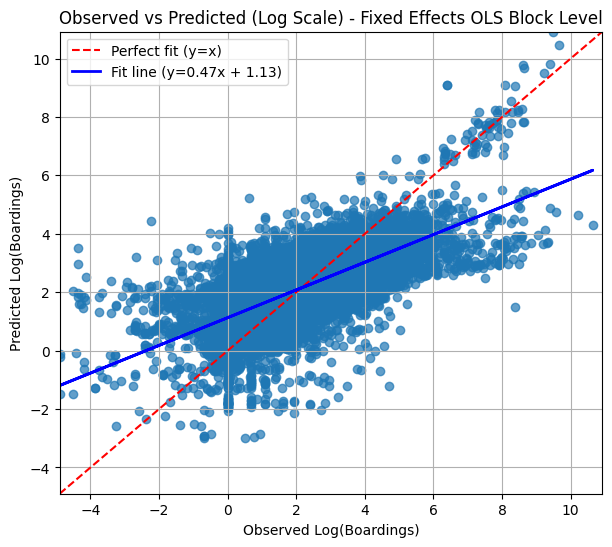

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Predicted and observed (log space)
log_pred = model.predict(X)
log_observed = df['log_boardings']

plt.figure(figsize=(7, 6))

plt.scatter(log_observed, log_pred, alpha=0.7)

# perfect fit line (y = x)
lims = [
    min(log_observed.min(), log_pred.min()),
    max(log_observed.max(), log_pred.max())
]

plt.plot(lims, lims, color="red", linestyle="--", label="Perfect fit (y=x)")

# fit line y = mx + c
m, c = np.polyfit(log_observed, log_pred, 1)
plt.plot(log_observed, m * log_observed + c,
         color="blue", linewidth=2,
         label=f"Fit line (y={m:.2f}x + {c:.2f})")

plt.xlim(lims)
plt.ylim(lims)

plt.xlabel("Observed Log(Boardings)")
plt.ylabel("Predicted Log(Boardings)")
plt.title("Observed vs Predicted (Log Scale) - Fixed Effects OLS Block Level")
plt.grid(True)
plt.legend()

plt.show()

In [21]:
from linearmodels.iv import IV2SLS

df = stop_route_df_selected_org.copy()

# Log transforms
df['log_boardings'] = np.log(df['average_daily_boardings'].replace(0, np.nan))
df['log_arrivals']  = np.log(df['n_arrivals'].replace(0, np.nan))

# Demographic rates (area ratio cancels in division)
df['pct_youth']     = df['total_youth_adj'] / df['total_pop_adj']
df['pct_lowincome'] = df['inc_total_lowincome_adj'] / df['total_pop_adj']
# df['pct_nocarhousehold']  = df['households_no_vehicle_adj'] / df['total_pop_adj']

df = df.dropna(subset=[
    'log_boardings', 'log_arrivals', 'land_use_index',
    'total_youth_adj', 'lowincome_total_adj',
    'organization_name', 'n_routes'
])

# Org fixed effects
org_fe = pd.get_dummies(df['organization_name'], drop_first=True).astype(float)

# Exogenous regressors (pct_no_car dropped - collinear with land_use_index)
exog = pd.concat([
    df[['land_use_index', 'total_youth_adj', 'lowincome_total_adj',]],
    org_fe
], axis=1)
exog = sm.add_constant(exog)

# Final IV-2SLS model
iv_final = IV2SLS(
    dependent=df['log_boardings'],
    exog=exog,
    endog=df[['log_arrivals']],   # endogenous: agencies add service where ridership is high
    instruments=df[['n_routes']]  # instrument: network supply decision, not demand-driven
).fit(cov_type='robust')

print(iv_final.summary)

# Diagnostics
print(iv_final.first_stage.summary)  # F > 10 confirms strong instrument
print(iv_final.wu_hausman())          # confirms IV was necessary over OLS

                          IV-2SLS Estimation Summary                          
Dep. Variable:          log_boardings   R-squared:                      0.4718
Estimator:                    IV-2SLS   Adj. R-squared:                 0.4714
No. Observations:               14198   F-statistic:                 1.386e+04
Date:                Wed, Jul 08 2026   P-value (F-stat)                0.0000
Time:                        19:14:30   Distribution:                 chi2(12)
Cov. Estimator:                robust                                         
                                                                              
                                               Parameter Estimates                                               
                                               Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-----------------------------------------------------------------------------------------------------------------
const                     

The Wu–Hausman test rejects the null hypothesis that the endogenous regressor is exogenous (F(1, 14172) = 12.65, p = 0.0004). This provides evidence of endogeneity, indicating that OLS estimates are inconsistent and supporting the use of the instrumental variables estimator.

In this model, the key methodological challenge is that log_arrivals (the number of scheduled transit arrivals at a stop) is endogenous, transit agencies don't randomly assign service, they add more buses and trains to stops that already have high ridership, meaning log_arrivals and the error term are correlated, which would bias OLS estimates. To correct for this, we use n_routes (the number of routes serving a stop) as an instrumental variable: it's a valid instrument because it strongly predicts how many arrivals a stop gets (more routes mechanically means more scheduled arrivals, strong first stage), but the number of routes serving a stop is a network-level planning decision that doesn't directly cause riders to board independently of the arrivals it generates (exclusion restriction). With log_arrivals instrumented by n_routes, the model then estimates the effect of service frequency on boardings alongside exogenous demand-side predictors — land use mix, share of low-income residents, share of youth, and share of disabled residents,  while controlling for agency-level fixed effects to absorb baseline differences in how each transit operator's stops perform.

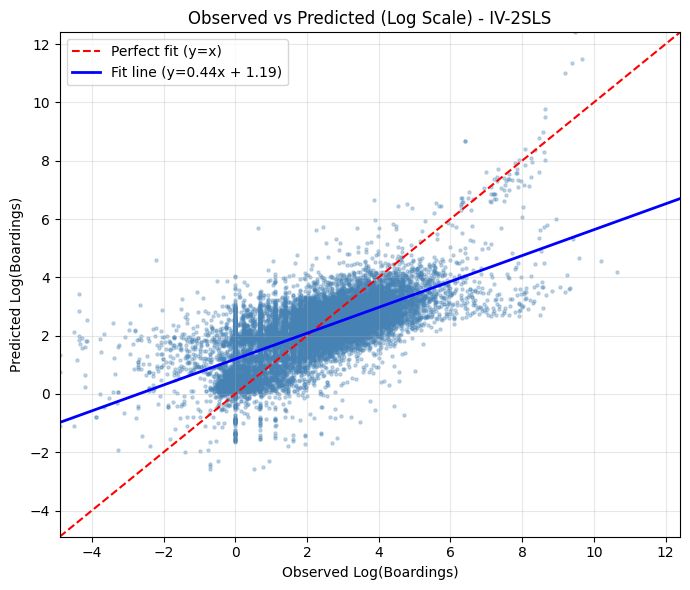

In [19]:
# Get fitted values and observed
log_pred     = iv_final.fitted_values.squeeze()
log_observed = df['log_boardings'].values

plt.figure(figsize=(7, 6))
plt.scatter(log_observed, log_pred, alpha=0.3, s=5, color='steelblue')

# Perfect fit line (y = x)
lims = [
    min(log_observed.min(), log_pred.min()),
    max(log_observed.max(), log_pred.max())
]
plt.plot(lims, lims, color="red", linestyle="--", label="Perfect fit (y=x)")

# Fit line y = mx + c
m, c = np.polyfit(log_observed, log_pred, 1)
plt.plot(np.array(lims), m * np.array(lims) + c,
         color="blue", linewidth=2,
         label=f"Fit line (y={m:.2f}x + {c:.2f})")

plt.xlim(lims)
plt.ylim(lims)
plt.xlabel("Observed Log(Boardings)")
plt.ylabel("Predicted Log(Boardings)")
plt.title("Observed vs Predicted (Log Scale) - IV-2SLS")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('iv_obs_vs_pred.png', dpi=150, bbox_inches='tight')
plt.show()

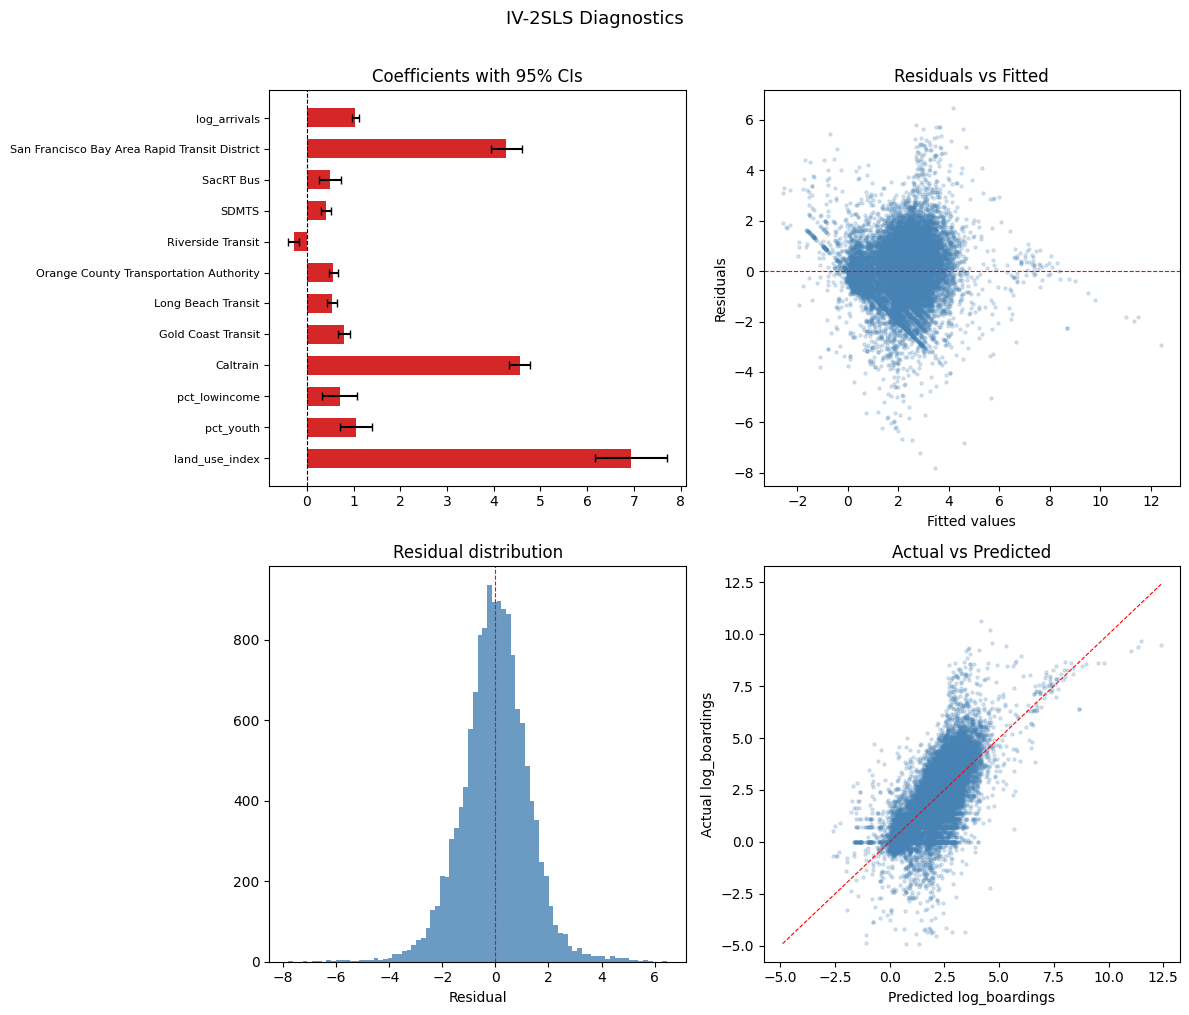

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

params = iv_final.params.drop('const')
ci     = iv_final.conf_int().drop('const')
fitted = iv_final.fitted_values.squeeze()
resid  = iv_final.resids.squeeze()
actual = df['log_boardings'].values

# 1. Coefficient plot
colors = ['#d62728' if ci.loc[v, 'lower'] > 0 or ci.loc[v, 'upper'] < 0
          else '#aec7e8' for v in params.index]
axes[0,0].barh(range(len(params)), params.values,
               xerr=[params.values - ci['lower'].values, ci['upper'].values - params.values],
               color=colors, capsize=3, height=0.6)
axes[0,0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0,0].set_yticks(range(len(params)))
axes[0,0].set_yticklabels(params.index, fontsize=8)
axes[0,0].set_title('Coefficients with 95% CIs')

# 2. Residuals vs fitted
axes[0,1].scatter(fitted, resid, alpha=0.2, s=5, color='steelblue')
axes[0,1].axhline(0, color='red', linewidth=0.8, linestyle='--')
axes[0,1].set_xlabel('Fitted values')
axes[0,1].set_ylabel('Residuals')
axes[0,1].set_title('Residuals vs Fitted')

# 3. Residual distribution
axes[1,0].hist(resid, bins=80, color='steelblue', edgecolor='none', alpha=0.8)
axes[1,0].axvline(0, color='red', linewidth=0.8, linestyle='--')
axes[1,0].set_xlabel('Residual')
axes[1,0].set_title('Residual distribution')

# 4. Actual vs predicted
axes[1,1].scatter(fitted, actual, alpha=0.2, s=5, color='steelblue')
mn, mx = min(fitted.min(), actual.min()), max(fitted.max(), actual.max())
axes[1,1].plot([mn, mx], [mn, mx], color='red', linewidth=0.8, linestyle='--')
axes[1,1].set_xlabel('Predicted log_boardings')
axes[1,1].set_ylabel('Actual log_boardings')
axes[1,1].set_title('Actual vs Predicted')

plt.suptitle('IV-2SLS Diagnostics', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('iv_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

- Coefficients with 95% CIs (top left).
- Residuals vs Fitted (top right): funnel shape — variance is small at low fitted values and explodes at high fitted values. This is heteroskedasticity, meaning standard errors are not constant.
- Residual Distribution (bottom left)
Roughly bell-shaped and centered on zero — good. It's slightly leptokurtic (taller and narrower than normal), meaning more extreme residuals than a normal distribution would predict.
